In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
import sys
print(sys.executable)

c:\Users\radha\AppData\Local\Programs\Python\Python311\python.exe


In [6]:
import seaborn as sns

print(sns.__version__)

0.13.2


In [7]:
df = pd.read_csv(r"C:\Users\radha\Downloads\Employee-Attrition - Employee-Attrition.csv")

In [8]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


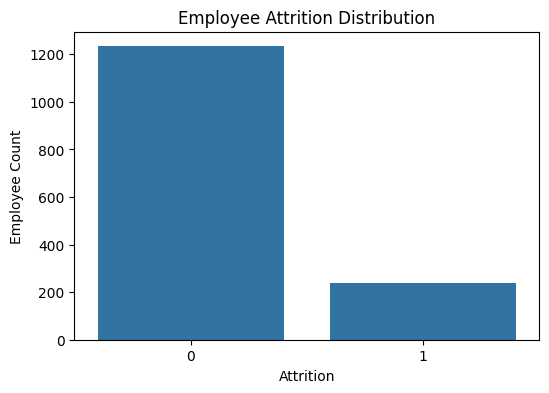

In [ ]:
#1. Attrition Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

plt.show()

In [ ]:
#The dataset is imbalanced, with most employees staying and a smaller proportion leaving the company.

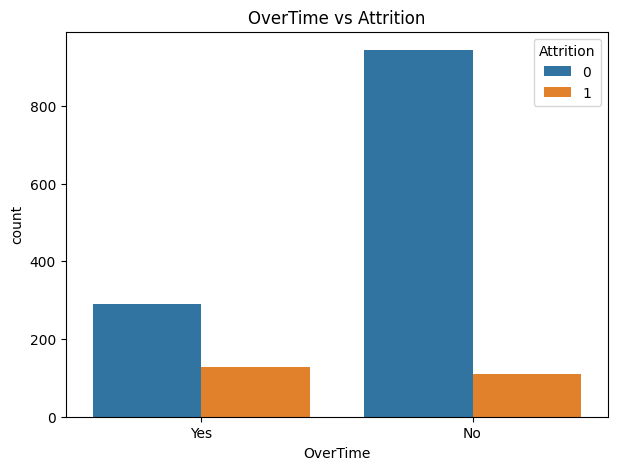

In [ ]:
#2. OverTime vs Attrition

plt.figure(figsize=(7,5))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("OverTime vs Attrition")
plt.show()

In [ ]:
#Employees working overtime show a noticeably higher attrition rate compared to employees who do not work overtime.

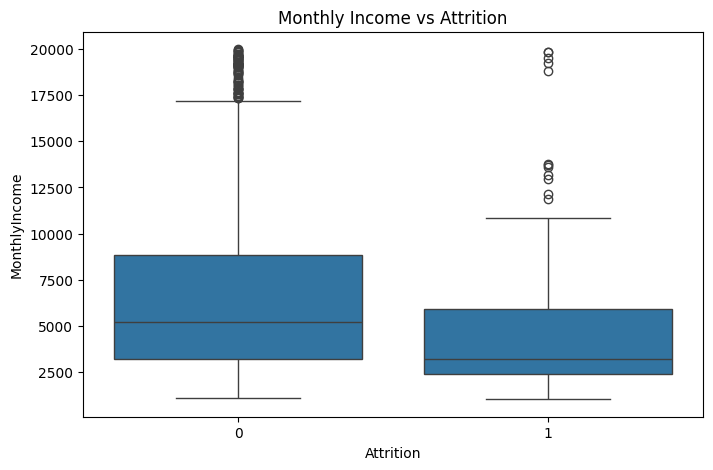

In [12]:
#3. MonthlyIncome vs Attrition

plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

In [ ]:
#Employees who left the organization tend to have lower monthly income compared to those who stayed.

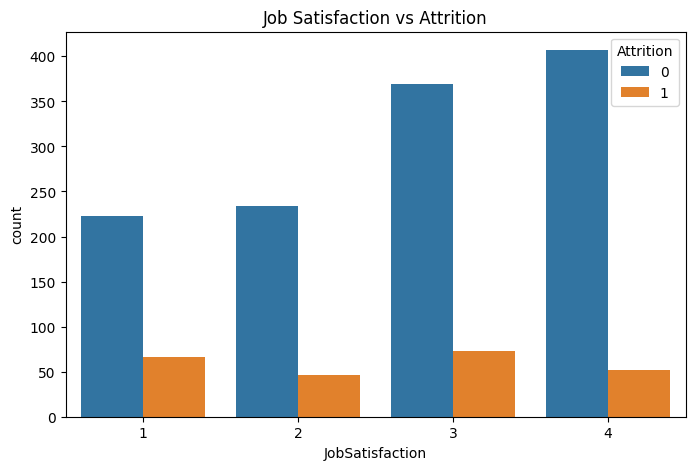

In [ ]:
#4, JobSatisfaction vs Attrition

plt.figure(figsize=(8,5))
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

In [ ]:
#Attrition is observed across all job satisfaction levels. A percentage-based analysis is required to determine whether lower job satisfaction is associated with higher attrition rates

In [22]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,0,1
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


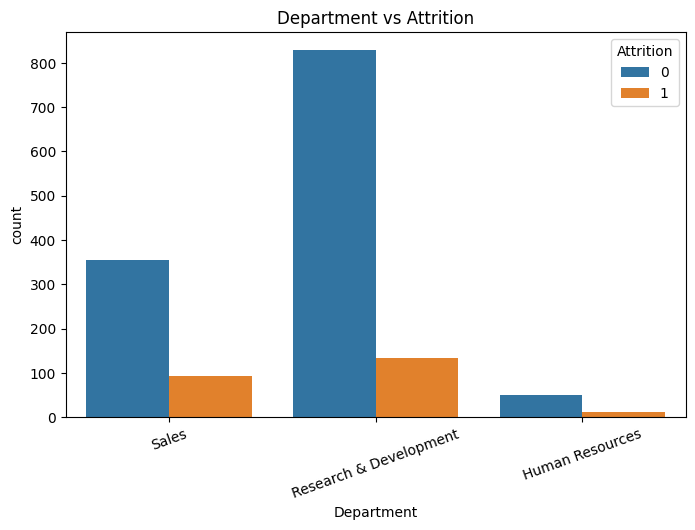

In [14]:
#5. Department vs Attrition

plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.xticks(rotation=20)
plt.title("Department vs Attrition")
plt.show()

In [ ]:
#Sales and Research & Development departments show higher attrition counts compared to Human Resources.

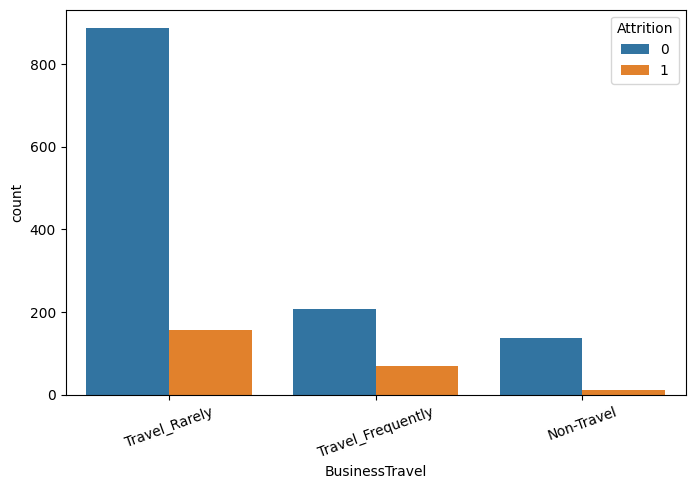

In [15]:
#6. BusinessTravel vs Attrition

plt.figure(figsize=(8,5))
sns.countplot(x="BusinessTravel", hue="Attrition", data=df)
plt.xticks(rotation=20)
plt.show()

In [ ]:
#Employees who travel frequently appear to have higher attrition compared to non-traveling employees.

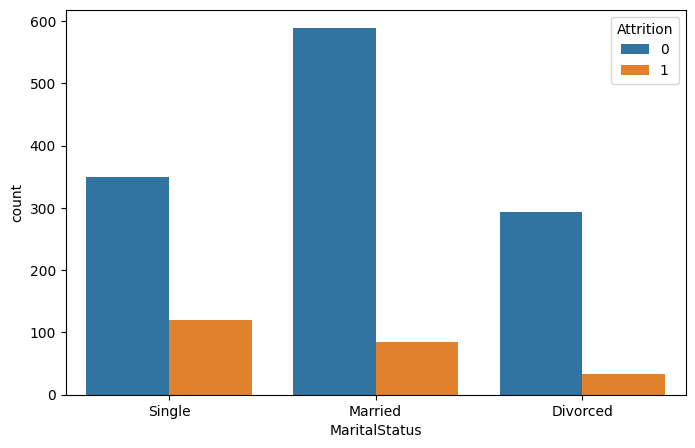

In [16]:
#7. MaritalStatus vs Attrition
plt.figure(figsize=(8,5))
sns.countplot(x="MaritalStatus", hue="Attrition", data=df)
plt.show()

In [ ]:
#Single employees show higher attrition counts compared to married employees.

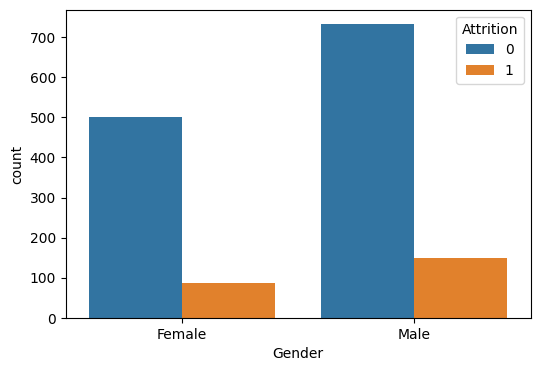

In [17]:
#8. Gender vs Attrition

plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Attrition", data=df)
plt.show()

In [ ]:
#Attrition is observed in both genders, with no major imbalance visible from the chart alone.

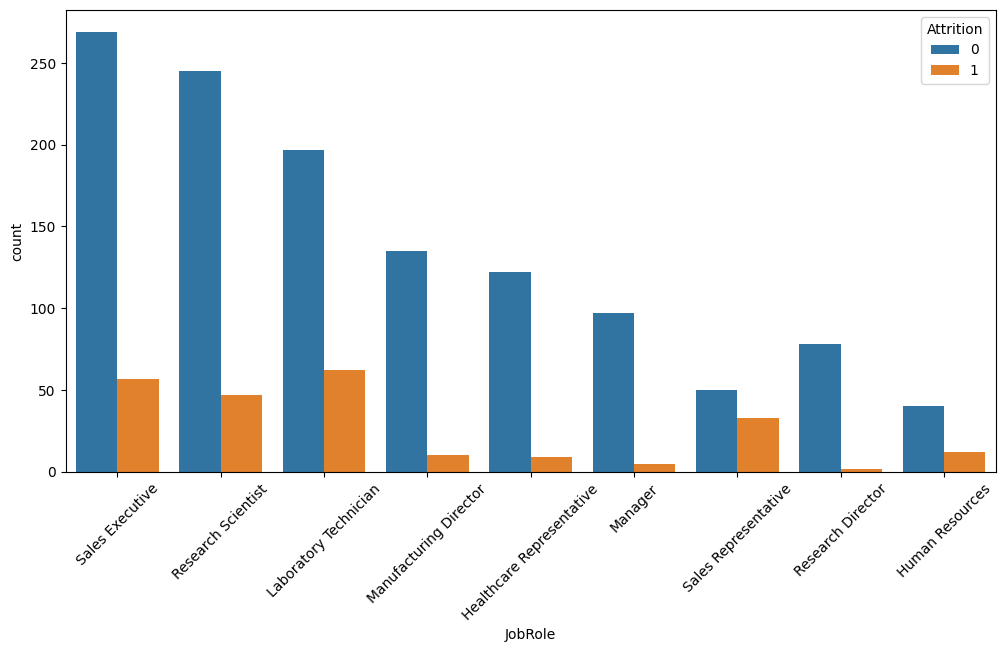

In [18]:
#9. JobRole vs Attrition
plt.figure(figsize=(12,6))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Sales Representatives and Laboratory Technicians exhibit relatively higher attrition compared to other roles.

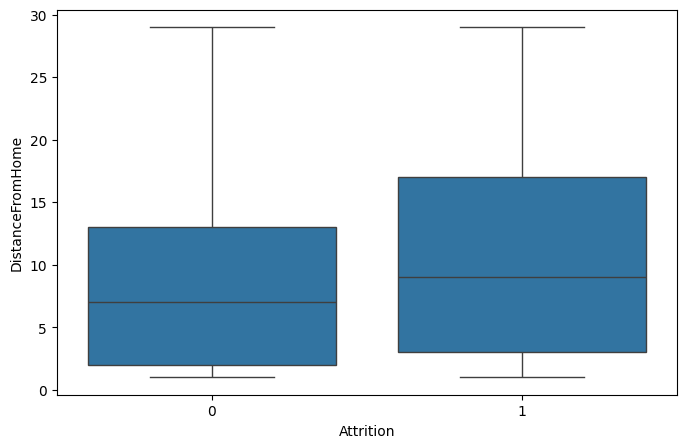

In [19]:
#10. DistanceFromHome vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="DistanceFromHome", data=df)
plt.show()

In [ ]:
#Employees who left the company tend to have a slightly wider distribution of commuting distances.

In [ ]:
#Correlation Heatmap

numeric_df = df.select_dtypes(include=["int64","float64"])

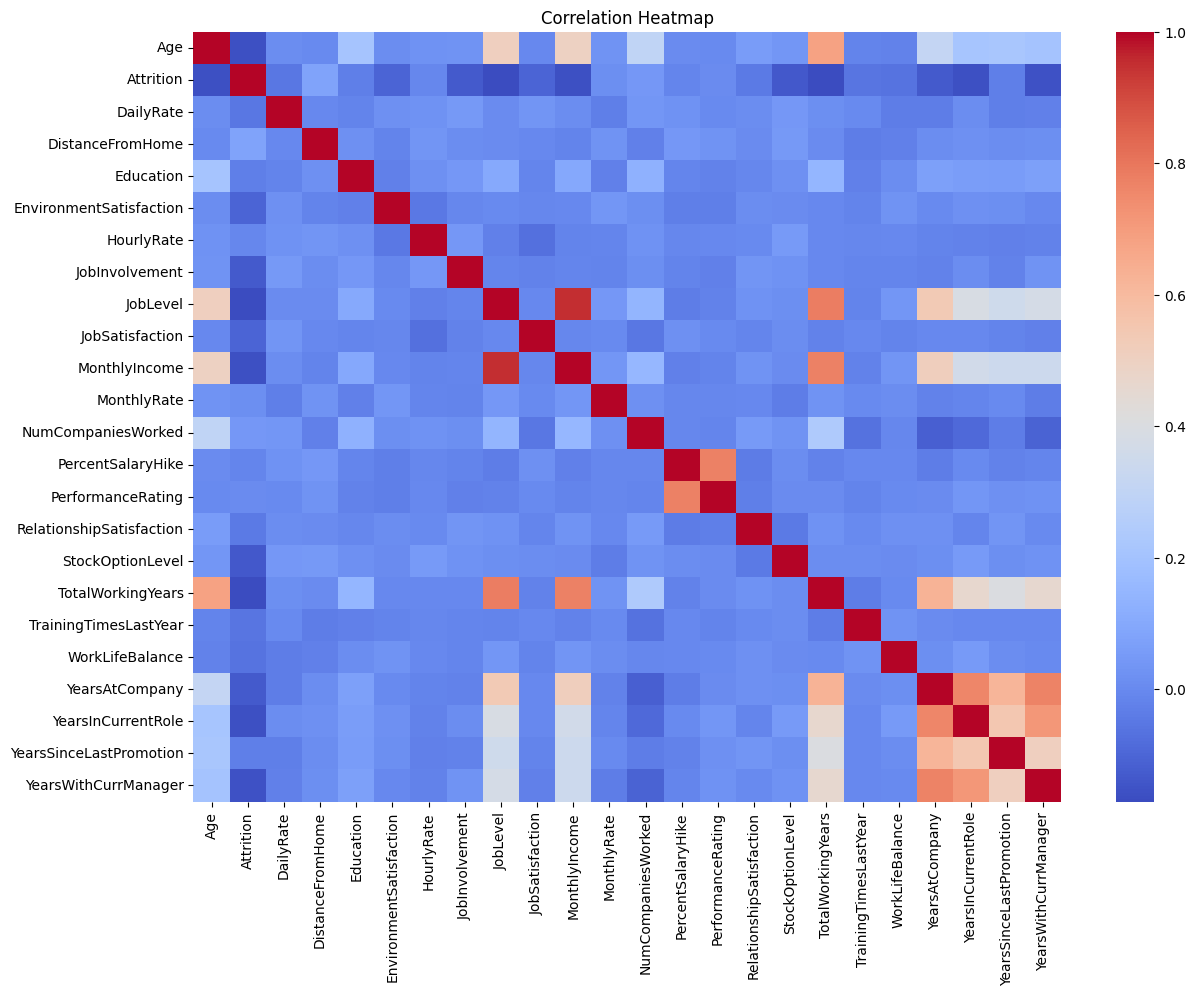

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#The correlation heatmap was used to identify relationships between numerical features. Most variables show weak to moderate correlations, indicating that each feature contributes unique information. Strong positive correlations were observed between variables such as JobLevel, MonthlyIncome, and TotalWorkingYears, suggesting that employees at higher job levels and with more experience tend to earn higher salaries. No severe multicollinearity was observed among most features.